In [7]:
import os
import torch
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from transformers import CLIPProcessor, CLIPModel

# Defaults
NUM_CLUSTERS = 2
IMAGE_FOLDER = "Dataset/test/images/"
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

all_embeddings = []
valid_image_paths = []

device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
# model / processor instances
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 63155.76it/s]


In [9]:
with torch.no_grad():
    for filename in os.listdir(IMAGE_FOLDER):
        if filename.lower().endswith(VALID_EXTENSIONS):
            image_path = os.path.join(IMAGE_FOLDER, filename)

            try:
                # load, transform and get embeddints
                image = Image.open(image_path).convert("RGB")
                inputs = processor(images=image, return_tensors="pt").to(device)
                embedding = model.get_image_features(**inputs)

                # normalize
                vision_tensor = embedding.pooler_output
                normalized_tensor = vision_tensor / vision_tensor.norm(
                    p=2, dim=-1, keepdim=True
                )

                embeddings_numpy = normalized_tensor.detach()

                # add to list
                all_embeddings.append(embeddings_numpy.cpu().numpy().flatten())
                valid_image_paths.append(image_path)

            except Exception as e:
                print(f"Skipping corrupt image {filename}: {e}")

In [10]:
# simple clustering model
embeddings_matrix = np.vstack(all_embeddings)
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=67, n_init="auto")
cluster_labels = kmeans.fit_predict(embeddings_matrix)

print("\nClustering Results:")
for path, label in zip(valid_image_paths, cluster_labels):
    print(f"Cluster {label}: {os.path.basename(path)}")


Clustering Results:
Cluster 1: DT (98).jpg
Cluster 0: BT (285).jpg
Cluster 1: DT (77).jpg
Cluster 1: DT (337).jpg
Cluster 1: DT (272).jpg
Cluster 0: BT (143).jpg
Cluster 1: DT (419).jpg
Cluster 1: DT (20).jpg
Cluster 0: BT (83).jpg
Cluster 1: DT (360).jpg
Cluster 0: BT (114).jpg
Cluster 1: DT (225).jpg
Cluster 0: BT (95).jpg
Cluster 1: DT (36).jpg
Cluster 1: DT (376).jpg
Cluster 1: DT (233).jpg
Cluster 1: DT (399).jpg
Cluster 0: BT (102).jpg
Cluster 1: DT (458).jpg
Cluster 0: BT (339).jpg
Cluster 1: DT (61).jpg
Cluster 0: BT (293).jpg
Cluster 1: DT (321).jpg
Cluster 0: BT (155).jpg
Cluster 1: DT (264).jpg
Cluster 1: DT (423).jpg
Cluster 0: BT (342).jpg
Cluster 0: BT (56).jpg
Cluster 0: BT (207).jpg
Cluster 1: DT (136).jpg
Cluster 0: BT (315).jpg
Cluster 1: DT (474).jpg
Cluster 1: DT (161).jpg
Cluster 0: BT (250).jpg
Cluster 1: DT (248).jpg
Cluster 0: BT (179).jpg
Cluster 0: BT (196).jpg
Cluster 1: DT (198).jpg
Cluster 1: DT (462).jpg
Cluster 0: BT (303).jpg
Cluster 0: BT (17).jpg
Clus


Reducing dimensions for visualization...


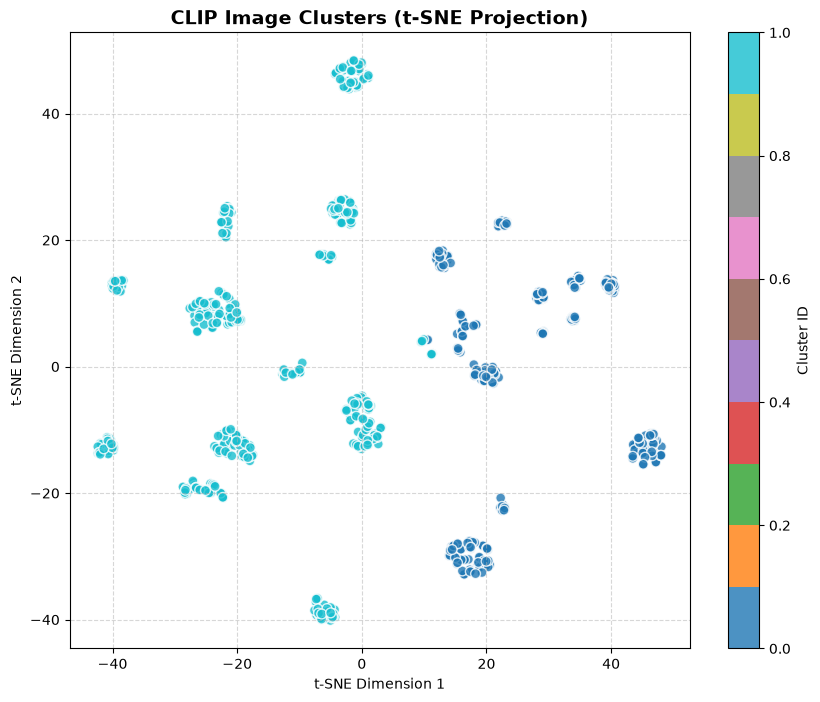

In [12]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

print("\nReducing dimensions for visualization...")

# 1. Compress 512 dimensions down to 2 dimensions
# perplexity should be smaller than your total number of images (default 30)
tsne = TSNE(
    n_components=2, perplexity=min(30, len(embeddings_matrix) - 1), random_state=42
)
embeddings_2d = tsne.fit_transform(embeddings_matrix)

# 2. Create the scatter plot
plt.figure(figsize=(10, 8))

# Map each unique cluster label to a distinct point color
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",  # Clean qualitative color palette
    alpha=0.8,
    edgecolors="w",
    s=50,
)

# 3. Add labels, title, and interactive legend
plt.title(f"CLIP Image Clusters (t-SNE Projection)", fontsize=14, fontweight="bold")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True, linestyle="--", alpha=0.5)

# 4. Display the visual chart window
plt.show()